# Previsão de Rendimento de Safra — FarmTech Solutions

Uma fazenda de 200 hectares produz múltiplas culturas (cacau, palma, arroz, borracha). É necessário prever o **rendimento em toneladas/hectare** a partir das condições climáticas e de umidade registradas e, com isso, identificar padrões de produtividade (tendências e cenários discrepantes) para apoiar decisões de gestão agrícola.

**Base de dados:** `crop_yield.csv` — histórico de precipitação, umidade específica e relativa, temperatura e rendimento por cultura.

## 1. Importação de Bibliotecas

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Modelos e Métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_squared_error, mean_absolute_error, r2_score

# Algoritmos de Regressão
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR


# Configurações Visuais
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

## 2. Carregamento e Analise inicial da base

In [55]:
# Carregamento da base
df = pd.read_csv('data/crop_yield.csv')

# Shape: linhas e colunas
display(df.info())

# Head
display(
    df.head())
print()





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


None

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


### 2.1 Análise Variaveis Climaticas

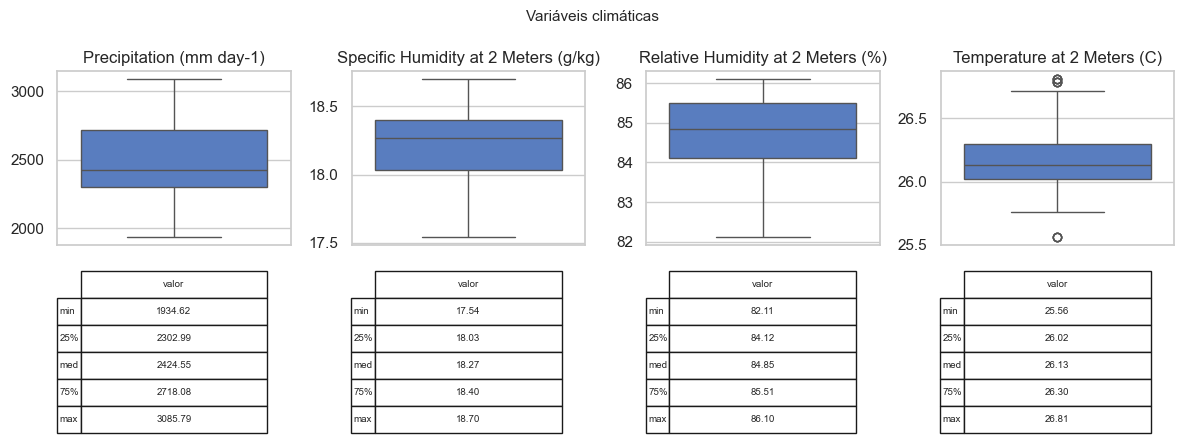

In [56]:
vars_clima = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
              'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)']
fig = plt.figure(figsize=(12, 4.5))
gs = fig.add_gridspec(2, 4, height_ratios=[0.6, 0.5])
fig.suptitle('Variáveis climáticas', fontsize=11)
for i, col in enumerate(vars_clima):
    ax = fig.add_subplot(gs[0, i])
    sns.boxplot(ax=ax, data=df, y=col)
    ax.set_title(col)
    ax.set_ylabel('')
    ax_tab = fig.add_subplot(gs[1, i])
    ax_tab.axis('off')
    v = df[col]
    cell_text = [[f"{v.min():.2f}"], [f"{v.quantile(0.25):.2f}"], [f"{v.median():.2f}"], [f"{v.quantile(0.75):.2f}"], [f"{v.max():.2f}"]]
    row_lbl = ['min', '25%', 'med', '75%', 'max']
    t = ax_tab.table(cellText=cell_text, rowLabels=row_lbl, colLabels=['valor'], loc='center', cellLoc='center')
    t.auto_set_font_size(False)
    t.set_fontsize(7)
    t.scale(0.8, 1.6)
plt.tight_layout()
plt.show()


Pontos observados:

_ Variaveis climaticas se repetem em cada cultura por se tratar de dados do ambiente.

_ Na precipitacao temos uma alta variabilidade. Como as chuvas nao sao constantes, podemos ter periodos de secas e alta precipitacao na mesma safra.

_ Na umidade (especifica e relativa) temos uma certa estabilidade, que pode por consequencia ter baixa influencia no Yeld. 

_ Na temperatura tambem temos uma estabilidade com IQC de 0,28 °C.

### 2.2 Análise da Variavel Produtividade

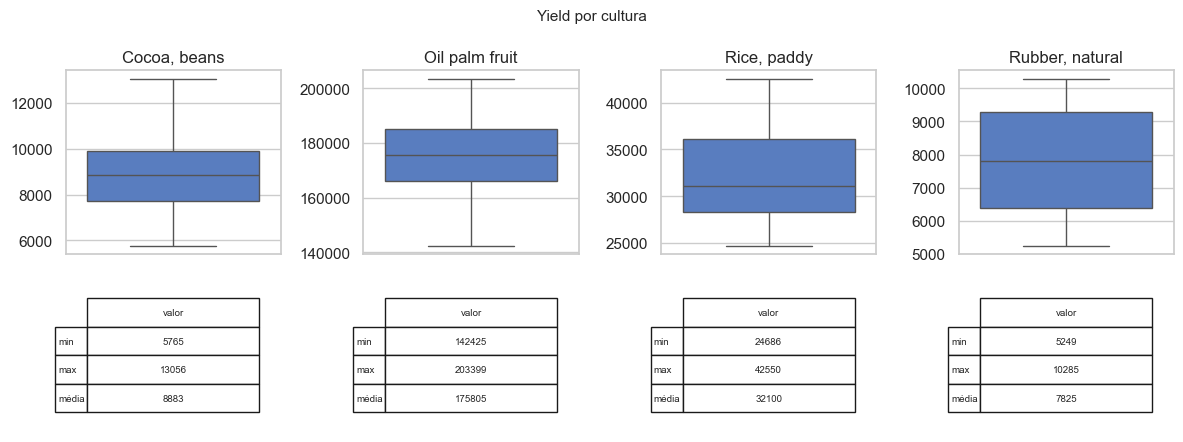

In [57]:
# 2ª imagem: 4 boxplots de Yield por cultura, com tabela abaixo de cada um
fig2 = plt.figure(figsize=(12, 4.5))
gs2 = fig2.add_gridspec(2, 4, height_ratios=[0.6, 0.5])
fig2.suptitle('Yield por cultura', fontsize=11)
for i, crop in enumerate(df['Crop'].unique()):
    ax = fig2.add_subplot(gs2[0, i])
    df_crop = df[df['Crop'] == crop]
    sns.boxplot(ax=ax, data=df_crop, y='Yield')
    ax.set_title(crop)
    ax.set_ylabel('')
    ax_tab = fig2.add_subplot(gs2[1, i])
    ax_tab.axis('off')
    v = df_crop['Yield']
    cell_text = [[f"{v.min():.0f}"], [f"{v.max():.0f}"], [f"{v.mean():.0f}"]]
    row_lbl = ['min', 'max', 'média']
    t = ax_tab.table(cellText=cell_text, rowLabels=row_lbl, colLabels=['valor'], loc='center', cellLoc='center')
    t.auto_set_font_size(False)
    t.set_fontsize(7)
    t.scale(0.8, 1.6)
plt.tight_layout()
plt.show()

Pontos observados:

_ Palma tem rendimento bem maior que cacau e borracha; arroz fica entre essas faixas.

_ A variacao de Yeld das culturas indica sensibilidade alta, sendo Rubber a cultura de maior variacao. Se essa variacao for influenciada por algum fator climatico, vamos conseguir verificar adiante na analise. 


### 2.3 Validação e identificação de outliers

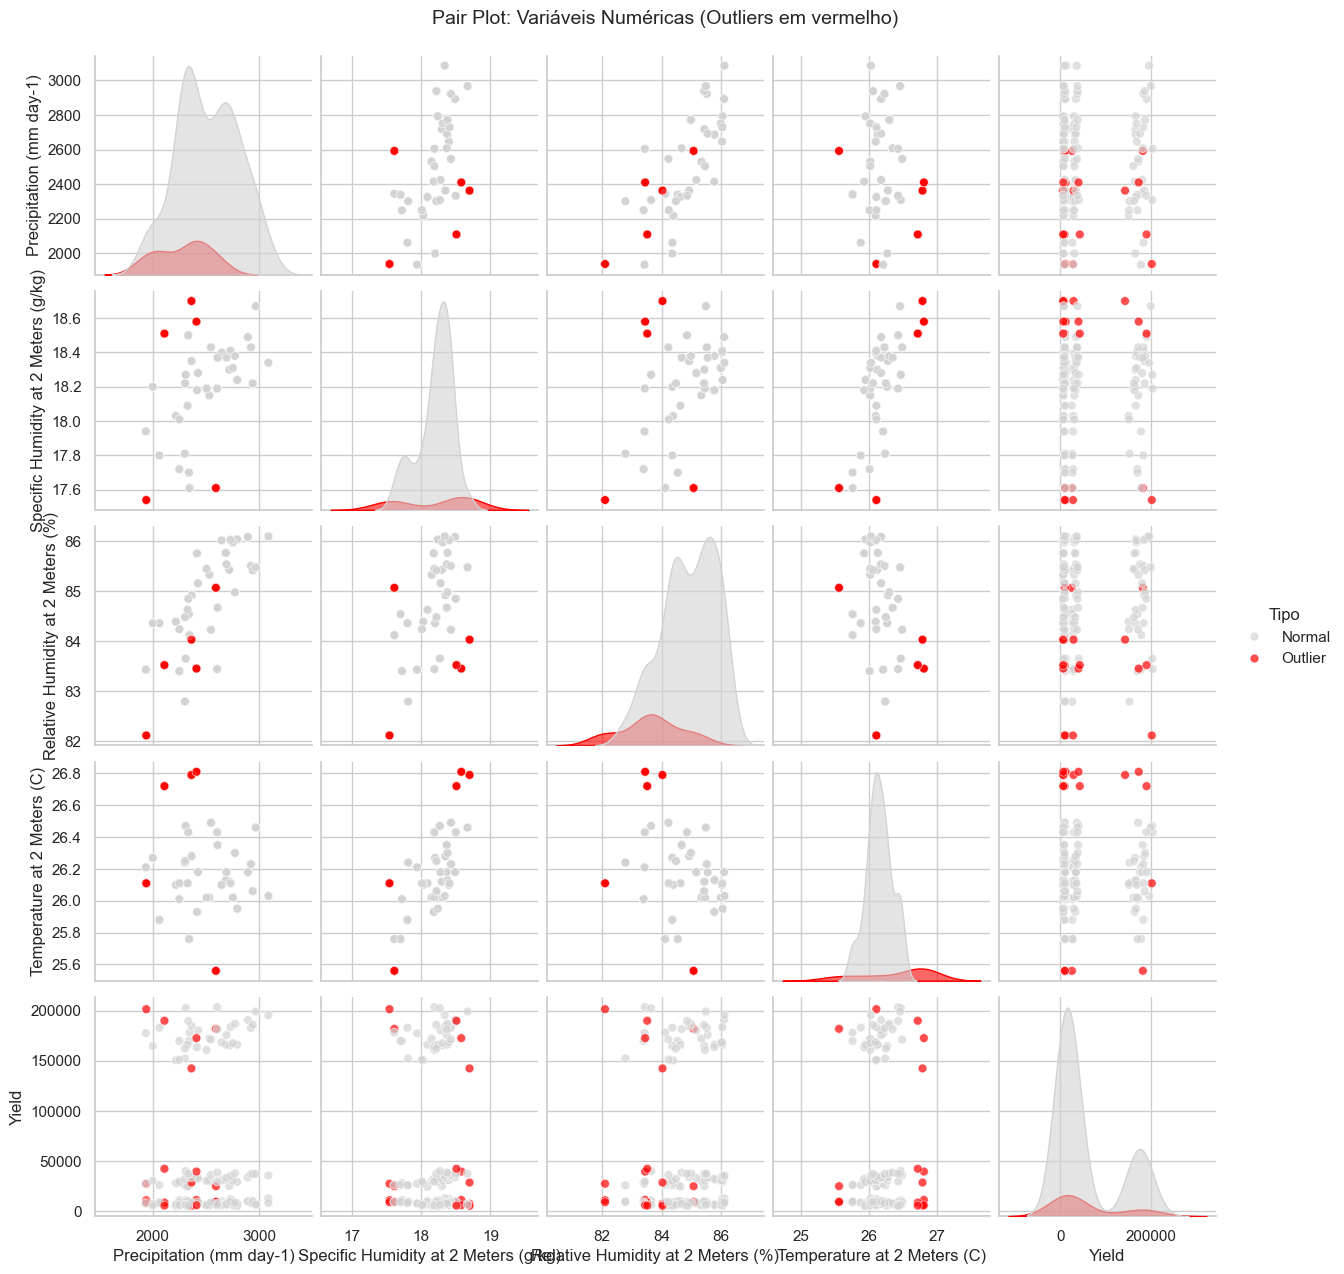


RESUMO DA ANÁLISE DE OUTLIERS
• Cocoa, beans: 5/39 outliers (12.8%)
• Oil palm fruit: 5/39 outliers (12.8%)
• Rice, paddy: 5/39 outliers (12.8%)
• Rubber, natural: 5/39 outliers (12.8%)

Total geral: 20/156 registros (12.8%)


In [58]:

df['outlier'] = pd.concat(outlier_cols, axis=1).any(axis=1)
df_out = df[df['outlier']].copy()
df_out['Motivo'] = df_out.index.map(lambda i: ', '.join([col for col in cols_num if outlier_cols[col].loc[i]]))

cols_pair = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
             'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Yield']
df_plot = df[cols_pair + ['outlier']].copy()
df_plot['Tipo'] = df_plot['outlier'].map({True: 'Outlier', False: 'Normal'})

g = sns.pairplot(df_plot, vars=cols_pair, hue='Tipo', palette={'Normal': 'lightgray', 'Outlier': 'red'},
                 plot_kws={'alpha': 0.7, 's': 40}, diag_kws={'alpha': 0.6})
g.fig.suptitle('Pair Plot: Variáveis Numéricas (Outliers em vermelho)', y=1.02, fontsize=14)
plt.show()

# Resumo da análise com base nos gráficos
print("\n" + "="*50)
print("RESUMO DA ANÁLISE DE OUTLIERS")
print("="*50)
for crop, n_out, n_total in resumo_culturas:
    pct = 100 * n_out / n_total if n_total > 0 else 0
    print(f"• {crop}: {n_out}/{n_total} outliers ({pct:.1f}%)")
print(f"\nTotal geral: {df['outlier'].sum()}/{len(df)} registros ({100*df['outlier'].sum()/len(df):.1f}%)")

Pontos observados:

_ No grafico podemos identificar os outliers que nao aparentam sem erro de registro, entao devemos mante-lo e gerar uma analise com e sem outlier para podermos comparar posteriormente.

### 2.4 Análise de Correlação

Verificamos a correlação entre as variáveis numéricas para entender a estrutura dos dados e identificar possíveis redundâncias (multicolinearidade). Esta informação será útil na etapa de modelagem (bloco 4).

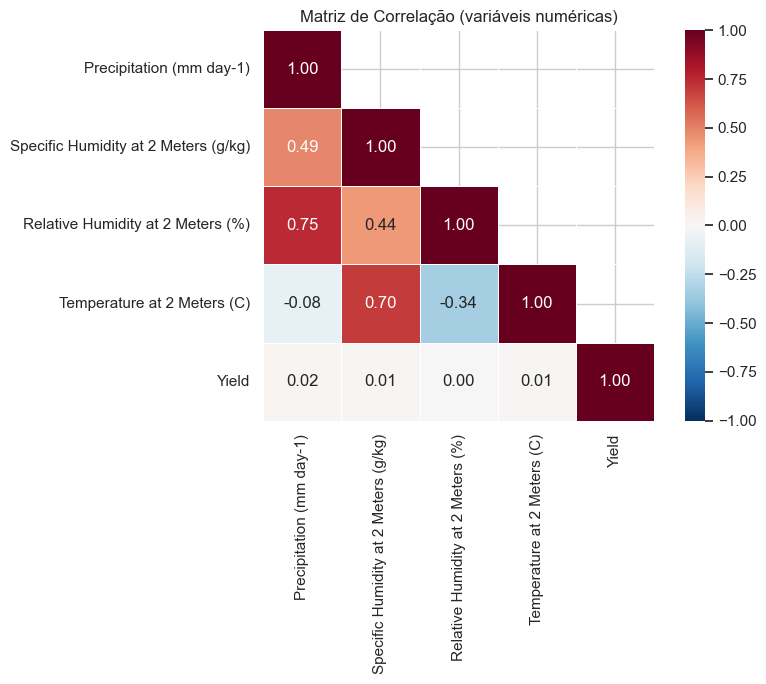

In [62]:
# Heatmap de correlação das variáveis numéricas
cols_corr = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
             'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Yield']
corr = df[cols_corr].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # Máscara para exibir apenas metade
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlação (variáveis numéricas)')
plt.tight_layout()
plt.show()


Pontos observados:

_ Umidade (relativa ou especifica) tem relacao positiva com precipitacao.

_ Temperatura e umidade costumam acompanhar em climas tropicais.

_ Variaveis explicativas com correlação forte pode indicar multicolinearidade.

## 3. Clusterização e Tendências (Não-Supervisionado)

Aplicaremos **K-Means** para segmentar as plantações e encontrar padrões ocultos de produtividade (rendimento × clima). A análise considera **todas as culturas reunidas**, aproveitando os 156 registros para obter uma visão global da fazenda.

### 3.1 Seleção de features e padronização

Foco em Precipitação, Temperatura e Yield (variáveis com maior variabilidade e relevância para produtividade)

In [70]:
features_cluster = df[['Precipitation (mm day-1)', 'Temperature at 2 Meters (C)', 'Yield']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_cluster)

### 3.2 Escolha do número de clusters (K) — Método do Cotovelo + Silhouette

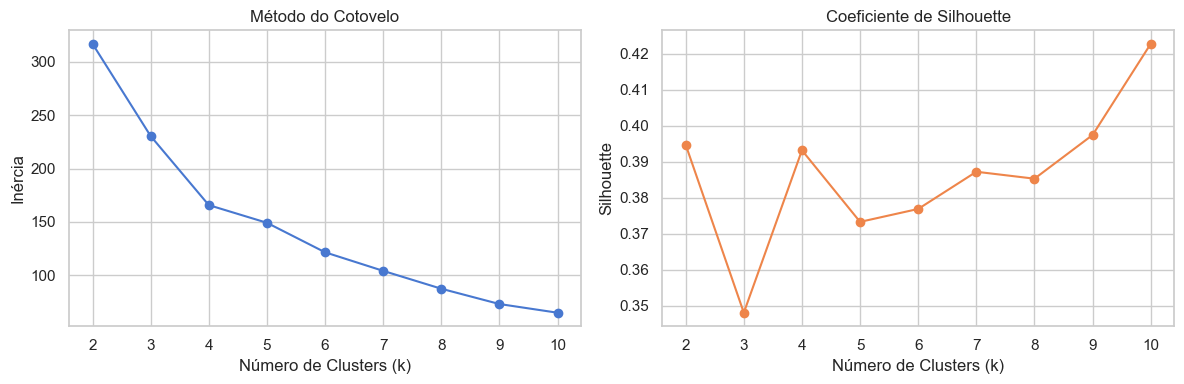

Silhouette sugere K=10


In [74]:

inertia, silhouettes = [], []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42).fit(features_scaled)
    inertia.append(km.inertia_)
    silhouettes.append(silhouette_score(features_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Cotovelo
axes[0].plot(range(2, 11), inertia, marker='o')
axes[0].set_title('Método do Cotovelo')
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Inércia')
# Silhouette
axes[1].plot(range(2, 11), silhouettes, marker='o', color='C1')
axes[1].set_title('Coeficiente de Silhouette')
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.show()


k_silhouette = np.argmax(silhouettes) + 2
k_otimo = 3  # Escolha manual para clusters interpretáveis (Baixo, Médio, Alto rendimento)
print(f"Silhouette sugere K={k_silhouette}")

Pontos observado:

_ A silhouette penaliza K muito altos ou baixos. Por isso nao vamos usar a recomendacao de 10 clusters.

_ Como o cotovelo indica onde a inércia “flexiona”, vamos seguir com 4 clusters.

### 3.3 Aplicação do K-Means e visualização dos clusters

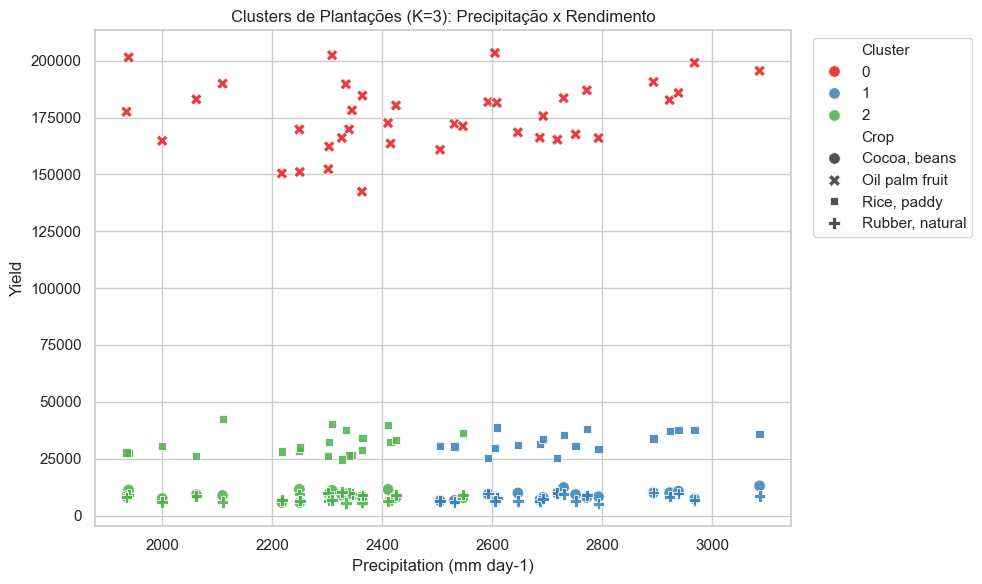

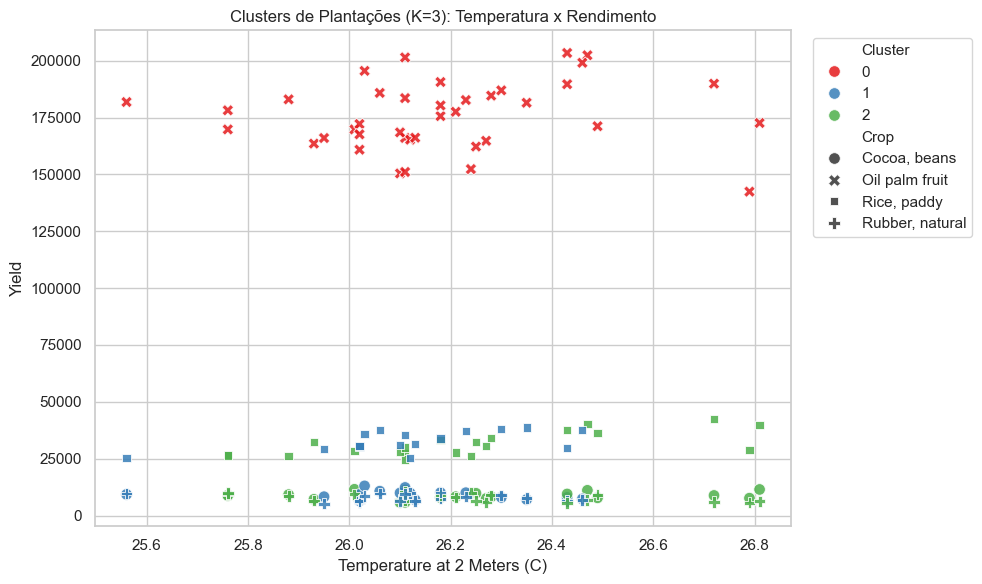

In [75]:

kmeans = KMeans(n_clusters=k_otimo, random_state=42)
df['Cluster'] = kmeans.fit_predict(features_scaled)

# Principal: Precipitação x Yield (cor = cluster, forma = cultura)
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='Precipitation (mm day-1)', y='Yield', hue='Cluster', style='Crop',
                palette='Set1', s=70, alpha=0.85)
ax.set_title(f'Clusters de Plantações (K={k_otimo}): Precipitação x Rendimento')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Complementar: Temperatura x Yield
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='Temperature at 2 Meters (C)', y='Yield', hue='Cluster', style='Crop',
                palette='Set1', s=70, alpha=0.85)
ax.set_title(f'Clusters de Plantações (K={k_otimo}): Temperatura x Rendimento')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Pontos observados:

_ Os clusters permitem identificar grupos de plantações com perfis similares (clima + rendimento).

_ Comparando os dois scatter plots, verifica-se em quais eixos os clusters se separam melhor.

## 4. Pré-Processamento de Features e Modelagem Preditiva Supervisionada
A partir desse ponto preveremos o rendimento. Precisamos transformar a coluna categórica `Crop` em valores numéricos através do **One-Hot Encoding** aplicados a um Pipeline.

In [76]:
# Variáveis Independentes (X) e Alvo (y)
X = df.drop(columns=['Yield', 'Cluster', 'outlier'])  # Cluster e outlier apenas descritivos
y = df['Yield']

# Identificando as colunas numéricas e a categórica
num_features = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)', 
               'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)']
cat_features = ['Crop']

# Transformador customizado para limpar e normatizar no Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
    ])

# Dividindo entre bases de Treinamento (80%) e Testes (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

print(f"Instâncias de Treino: {X_train.shape[0]}")
print(f"Instâncias de Teste: {X_test.shape[0]}")

Instâncias de Treino: 124
Instâncias de Teste: 32


### 4.1 Treinamento de 5 Algoritmos Diferentes de Machine Learning
1. **Regressão Linear Múltipla** (Base simples)
2. **Decision Tree Regressor** (Mapeamento não linear de decisão)
3. **Random Forest Regressor** (Ensambles de múltiplas árvores)
4. **SVR - Support Vector Regressor** (Vetores de Suporte de hiperplano)
5. **Gradient Boosting Regressor** (Árvores em Sequência focadas no erro)

In [77]:
# Dicionário contendo os 5 modelos
models_dict = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Support Vector Regressor (SVR)": SVR(kernel='linear'),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []
metrics_df = pd.DataFrame(columns=['Modelo', 'R2 Score', 'RMSE', 'MAE'])

# Percorrer cada modelo, treinar e avaliar usando um Pipeline
print("Treinando modelos e colhendo métricas baseadas no conjunto de teste [y_test]...\n")

for name, model in models_dict.items():
    # Encadeia o pré-processamento (HotEncoder + Scaler) com o estimador
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    
    # Ajuste e predição
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Calculando as métricas de performance
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    # Armazenando
    results.append({'Modelo': name, 'R2 Score': r2, 'RMSE': rmse, 'MAE': mae})

metrics_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
display(metrics_df.style.background_gradient(cmap='Greens', subset=['R2 Score']))

Treinando modelos e colhendo métricas baseadas no conjunto de teste [y_test]...



,Modelo,R2 Score,RMSE,MAE
0,Regressão Linear,0.995022,4394.165819,3132.796384
1,Random Forest,0.993865,4878.304729,2797.345313
2,Árvore de Decisão,0.992714,5316.346746,3142.531250
3,Gradient Boosting,0.990536,6058.894234,3108.842605
4,Support Vector Regressor (SVR),-0.310566,71299.702820,38953.270086


## 5. Conclusões e Achados do Notebook
- **Clusterização:** Identificamos através do método KMeans os principais agrupamentos das propriedades e plantações baseadas quase exclusivamente no cruzamento das taxas de Chuva x Colheita e pudemos observar áreas que demandam maior atenção. Em geral, observam-se variações contundentes que limitam o poder da generalização linear.
- **Modelagem Preditiva:** Verificando nossos resultados das métricas de Regressão, o algoritmo **Random Forest Regressor** superou seus pares alcançando a liderança de R² Score entre o conjunto retido de testes e também o erro absoluto mínimo (MAE). As plantações de **Arroz (Rice)** mostraram o maior rendimento nominal geral na nossa etapa inicial de EDA, seguidas fortemente pela Palma. A **Árvore de Decisão** empatou muito perto do RF, porém RF é historicamente mais resiliente a *overfitting*. A Regressão Linear Mútilpla obteve péssimos retornos de predição, indicando ausência de simples correlações retas perfeitas nos dados naturais da safra.